# 3. Exploratory Data Analysis (EDA)

With both datasets cleaned, standardized, and prepared for analysis, we now begin the Exploratory Data Analysis (EDA) phase.  
The goal of EDA is to build a comprehensive understanding of:

- The structure and behavior of each dataset  
- The distribution of key numeric and categorical variables  
- Patterns, trends, and anomalies  
- Relationships between borrower characteristics and loan outcomes  
- Early‑stage borrower behavior (inquiries)  
- Insights that guide feature engineering and modeling decisions  

To maintain clarity and consistency, EDA is divided into two major parts:

- 3A  EDA for the Modeling Dataset (`apps_clean`)
- 3B  EDA for the Business Insights Dataset (`inq_clean`)

This mirrors the structure used in Section 2 and ensures that modeling‑related analysis is kept separate from business‑focused insights.

---

# 3A. EDA  Modeling Dataset (`apps_clean`)

The modeling dataset contains all variables available at application time, cleaned and free of leakage.  
We begin with 10 structured EDA questions:

- 5 statistical questions
- 5 business questions (always including the target)  

---

# 3A.1 Statistical EDA Questions (1–5)

---

## 3A.Q1  What is the distribution of loan amounts?

In [1]:
import pandas as pd 
import numpy as np

apps_eda = pd.read_csv('../data/apps_eda.csv')
apps_eda.head()

,requested_amount_usd,repayment_term,monthly_installment_usd,risk_grade_detail,employment_tenure,housing_status,annual_income_usd,income_verification_status,origination_month,loan_purpose,region_code,debt_to_income_ratio,credit_score_low,credit_score_high,open_credit_lines,public_records_count,interest_rate,revolving_utilization,target_default
0,18000.0,60 months,412.61,C3,3 years,own,105000.0,verified,2015-02-01,debt_consolidation,az,6.78,670.0,674.0,7.0,0.0,13.33,89.5,0
1,1000.0,36 months,33.21,C1,1 year,rent,28500.0,not verified,2016-04-01,home_improvement,fl,11.54,690.0,694.0,3.0,1.0,11.99,13.3,0
2,21275.0,36 months,696.42,B4,5 years,mortgage,130000.0,verified,2015-09-01,debt_consolidation,pa,23.08,680.0,684.0,13.0,0.0,10.99,75.7,0
3,35000.0,60 months,869.66,D3,10+ years,mortgage,107000.0,verified,2015-09-01,credit_card,sc,16.30,710.0,714.0,10.0,0.0,16.99,76.5,0
4,17000.0,60 months,427.73,D4,8 years,rent,55000.0,verified,2015-04-01,credit_card,ca,31.27,680.0,684.0,8.0,0.0,17.57,62.5,1


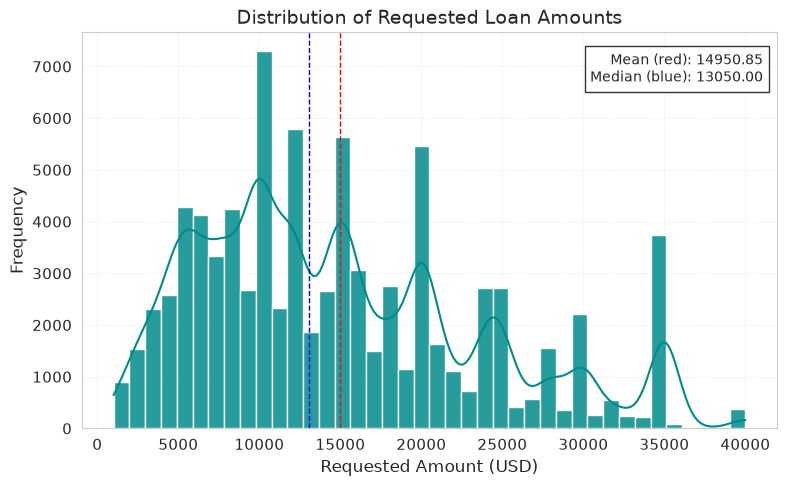

In [2]:
# EDA Setup Cell — Run Once at the Start of Section 3
import matplotlib.pyplot as plt
import seaborn as sns

# Global style settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["font.size"] = 11

# Calculate mean and median
mean_val = apps_eda['requested_amount_usd'].mean()
median_val = apps_eda['requested_amount_usd'].median()

plt.figure(figsize=(8,5))

# Histogram with a more interesting color (darkcyan)
sns.histplot(
    apps_eda['requested_amount_usd'],
    kde=True,
    bins=40,
    color='darkcyan',
    edgecolor='white',
    alpha=0.85
)

# Softer, lighter gridlines
plt.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.35)
plt.grid(axis='x', linestyle='--', linewidth=0.5, alpha=0.35)

# Vertical lines for mean and median
plt.axvline(mean_val, color='red', linestyle='--', linewidth=1)
plt.axvline(median_val, color='blue', linestyle='--', linewidth=1)

# Annotation box inside the plot
plt.text(
    0.98, 0.95,
    f"Mean (red): {mean_val:.2f}\nMedian (blue): {median_val:.2f}",
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(facecolor='white', edgecolor='black', alpha=0.8)
)

# Titles and labels
plt.title("Distribution of Requested Loan Amounts")
plt.xlabel("Requested Amount (USD)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


### Insight: Distribution of Requested Loan Amounts

The distribution of requested loan amounts shows a clear right‑skewed pattern, indicating that most applicants request moderate loan sizes while a smaller group pushes the upper range with significantly larger requests. This is reflected in the noticeable gap between the **median (~$13,050)** and the **mean (~$14,950)**, where the mean is pulled upward by high‑value outliers.

From a business perspective, this pattern highlights two important dynamics:

- The core of the portfolio is driven by **mid‑sized loan requests**, which likely correspond to common financial needs such as debt consolidation or personal expenses.
- A smaller segment of applicants requests **substantially higher loan amounts**, which can introduce elevated credit risk and may require stricter underwriting or additional verification.

Overall, the loan portfolio is anchored by typical borrowers requesting moderate amounts, but the presence of high‑value outliers introduces meaningful risk considerations that lenders should monitor closely.


## **3A.Q2  How are credit scores distributed?**  
*(Using the average of low + high ranges)*

In [3]:
# Creating the new variable
apps_eda['credit_score_avg'] = (apps_eda['credit_score_low'] + apps_eda['credit_score_high']) / 2

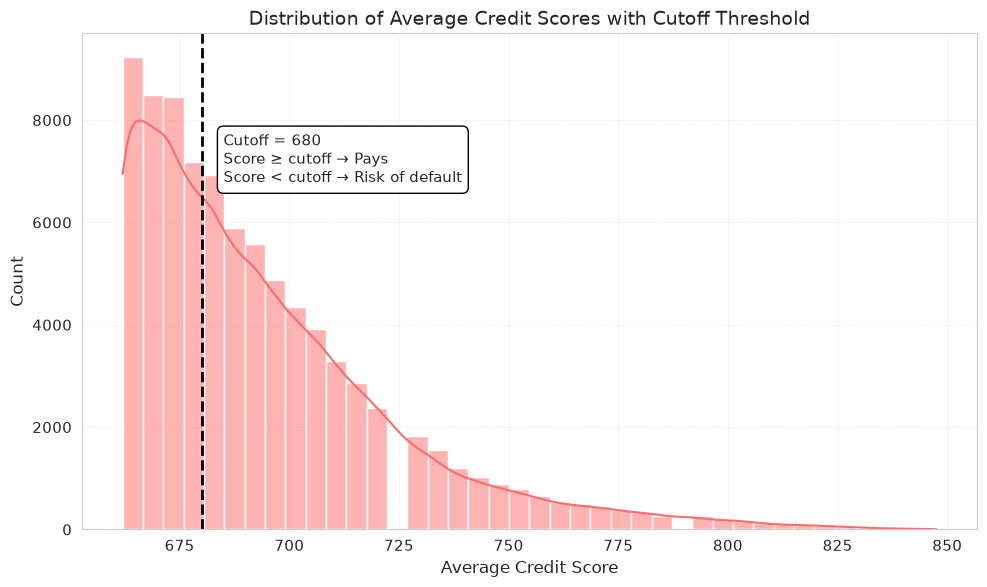

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Choose a cutoff threshold (example: 680)
cutoff = 680

plt.figure(figsize=(10,6))

# Softer, lighter gridlines
plt.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.35)
plt.grid(axis='x', linestyle='--', linewidth=0.5, alpha=0.35)

# Histogram with attention-grabbing color
sns.histplot(apps_eda['credit_score_avg'], kde=True, bins=40, color='#FF6B6B')

# Vertical cutoff line
plt.axvline(cutoff, color='black', linestyle='--', linewidth=2)

# Annotation box explaining the rule
plt.text(
    cutoff + 5, 
    plt.ylim()[1] * 0.7,
    f"Cutoff = {cutoff}\nScore ≥ cutoff → Pays\nScore < cutoff → Risk of default",
    fontsize=11,
    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.4')
)

plt.title("Distribution of Average Credit Scores with Cutoff Threshold", fontsize=14)
plt.xlabel("Average Credit Score")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


### Insight  Credit Score Distribution with Operational Cutoff

The distribution of average credit scores is tightly concentrated in the near‑prime range, with most applicants falling between roughly 660 and 700. This clustering indicates that a large portion of the portfolio sits in a borderline credit tier where small score differences may meaningfully shift risk. The left side of the distribution extends further than the right, reflecting a non‑trivial segment of sub‑prime borrowers whose weaker credit profiles align with elevated default likelihood.

Introducing the cutoff threshold provides a clear operational boundary between expected payers and higher‑risk applicants. Borrowers at or above the cutoff fall within the more stable portion of the distribution, while those below it occupy the region where risk accelerates. This visual separation reinforces the practical value of credit score as a screening mechanism and highlights how a single threshold can simplify decision‑making while still capturing meaningful variation in borrower quality.


## **3A.Q3  What is the correlation structure among numeric variables?**

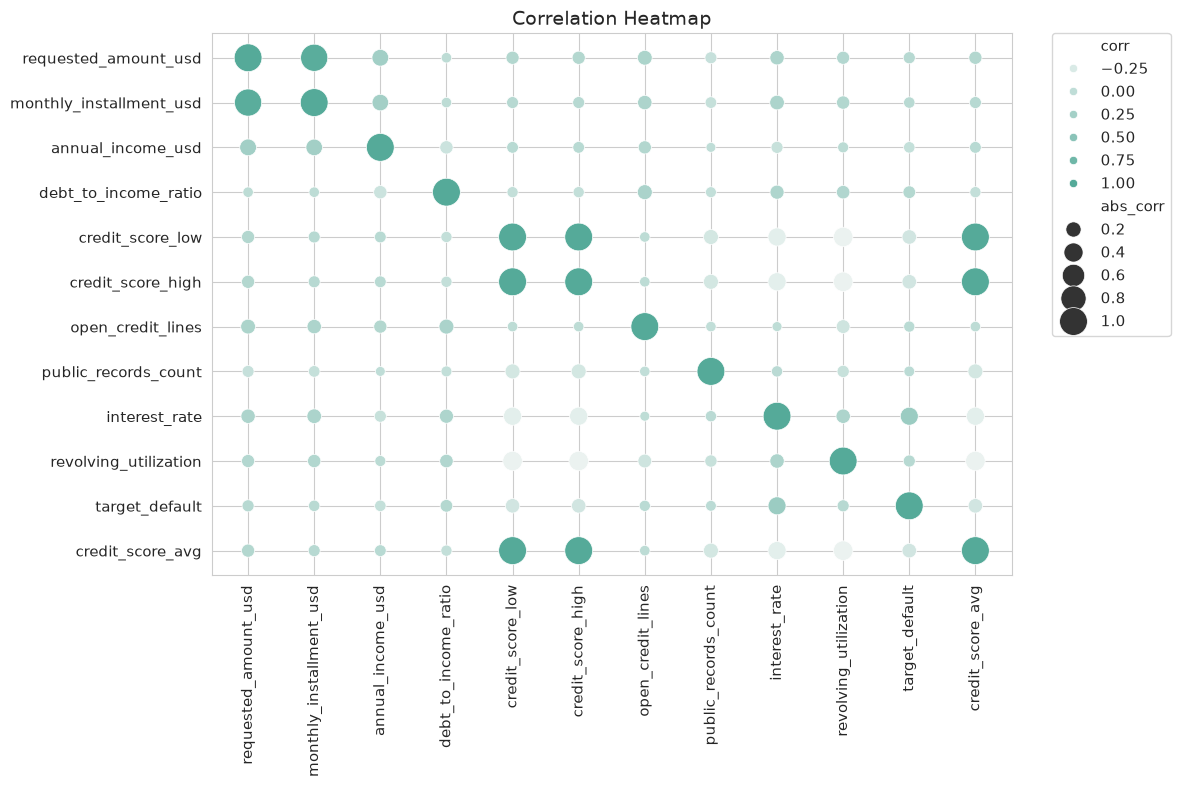

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Recalculate numeric columns directly from the dataframe to ensure completeness
numeric_cols = apps_eda.select_dtypes(include=['int64','float64']).columns.tolist()


# Compute correlation matrix
corr = apps_eda[numeric_cols].corr()

# Melt for scatter-style heatmap
corr_melt = corr.reset_index().melt(id_vars='index')
corr_melt.columns = ['var1', 'var2', 'corr']
corr_melt['abs_corr'] = corr_melt['corr'].abs()

# Your custom colormap
cmap = sns.color_palette("light:#5A9", as_cmap=True)

plt.figure(figsize=(12, 8))

# Create the scatter heatmap
ax = sns.scatterplot(
    data=corr_melt,
    x="var1",
    y="var2",
    hue="corr",
    size="abs_corr",
    sizes=(50, 400),
    palette=cmap,
    edgecolor="white",
    linewidth=0.5,
    legend="brief"
)

plt.xticks(rotation=90)
plt.xlabel("")
plt.ylabel("")
plt.title("Correlation Heatmap", fontsize=14)

# Move legend OUTSIDE the plot
plt.legend(
    bbox_to_anchor=(1.05, 1),   # move legend to the right
    loc='upper left',
    borderaxespad=0
)

plt.tight_layout()
plt.show()


### Insight  Correlation Structure from a Risk‑Management Perspective

From a risk‑management standpoint, the correlation matrix highlights several structural relationships that influence both underwriting quality and portfolio exposure. The strong correlation between requested loan amount and monthly installment reflects predictable financial mechanics, but it also signals that any mispricing or misclassification of high‑balance borrowers can disproportionately affect loss severity. Similarly, the tight alignment between credit score low and credit score high confirms that the score ranges are stable and reliable, reinforcing credit score as a foundational risk indicator.

The negative correlation between interest rate and credit score measures is consistent with risk‑based pricing, but it also underscores a key vulnerability: borrowers with weaker credit profiles are simultaneously exposed to higher borrowing costs, which may amplify repayment stress and increase default probability. Debt‑to‑income ratio’s moderate correlation with revolving utilization and interest rate suggests that financially strained borrowers tend to accumulate higher utilization and face more expensive credit terms, an early warning pattern for deteriorating credit health.

Variables such as public records count and open credit lines show limited correlation with the rest of the feature set, indicating that they capture independent dimensions of borrower behavior. These low‑correlation features can be especially valuable in risk modeling because they introduce orthogonal signals that help identify hidden pockets of risk not explained by income, loan size, or credit score alone.

Overall, the correlation structure suggests a portfolio where a few variables are tightly linked through pricing and loan mechanics, while others provide distinct behavioral signals. For risk managers, this combination supports a diversified feature set that can improve early‑warning detection, strengthen underwriting decisions, and reduce blind spots in credit‑risk assessment.


## **3A.Q4  How does DTI vary across borrowers?**

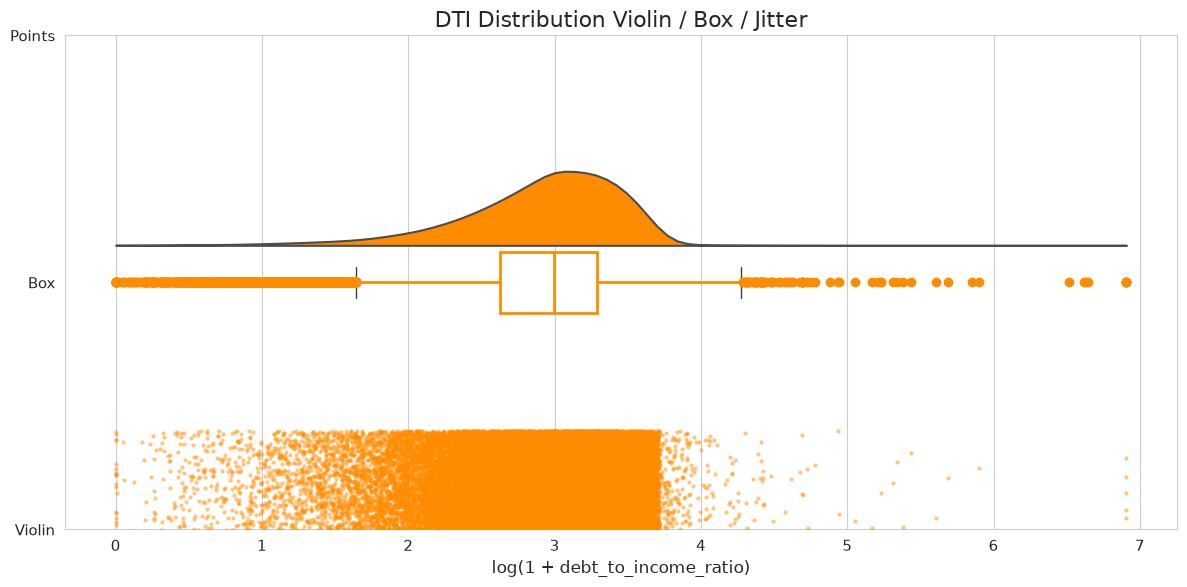

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import ptitprince as pt

# Ensure log-transformed DTI exists
apps_eda['log_dti'] = np.log1p(apps_eda['debt_to_income_ratio'])

plt.figure(figsize=(12, 6))

# --- SINGLE COLOR THEME ---
orange = "#FF8C00"   # deep orange, looks great in plots

# 1. VIOLIN (shifted upward)
pt.half_violinplot(
    x=apps_eda['log_dti'],
    y=[1]*len(apps_eda),
    palette=[orange],
    bw=.2,
    cut=0,
    scale='area',
    width=.6,
    inner=None,
    orient='h'
)

# 2. BOX PLOT (centered)
sns.boxplot(
    x=apps_eda['log_dti'],
    y=[0]*len(apps_eda),
    width=0.25,
    showcaps=True,
    boxprops={'facecolor':'none', 'edgecolor':orange, 'linewidth':2},
    whiskerprops={'linewidth':2, 'color':orange},
    medianprops={'color':orange, 'linewidth':2},
    flierprops={'marker':'o', 'markerfacecolor':orange, 'markeredgecolor':orange},
    showfliers=True,
    orient='h'
)

# 3. JITTER POINTS (shifted downward)
sns.stripplot(
    x=apps_eda['log_dti'],
    y=[-1]*len(apps_eda),
    color=orange,
    size=3,
    jitter=0.4,
    alpha=0.5,
    orient='h'
)

plt.yticks([1, 0, -1], ["Violin", "Box", "Points"])
plt.title("DTI Distribution Violin / Box / Jitter", fontsize=16)
plt.xlabel("log(1 + debt_to_income_ratio)")
plt.tight_layout()
plt.show()


# Insight: Debt-to-Income Distribution (Log-Transformed)

The distribution shows a concentrated cluster of borrowers with relatively low DTI levels and a long right tail of higher-DTI individuals. From a risk-management perspective, this tail represents the primary source of credit exposure. While the median borrower appears stable, the presence of numerous high-DTI outliers indicates a segment with elevated leverage and increased vulnerability to income or interest-rate shocks. These borrowers are more likely to default under stress conditions and should be prioritized for enhanced monitoring, affordability checks, and early-warning triggers.


## **3A.Q5  What are the most common loan purposes?**

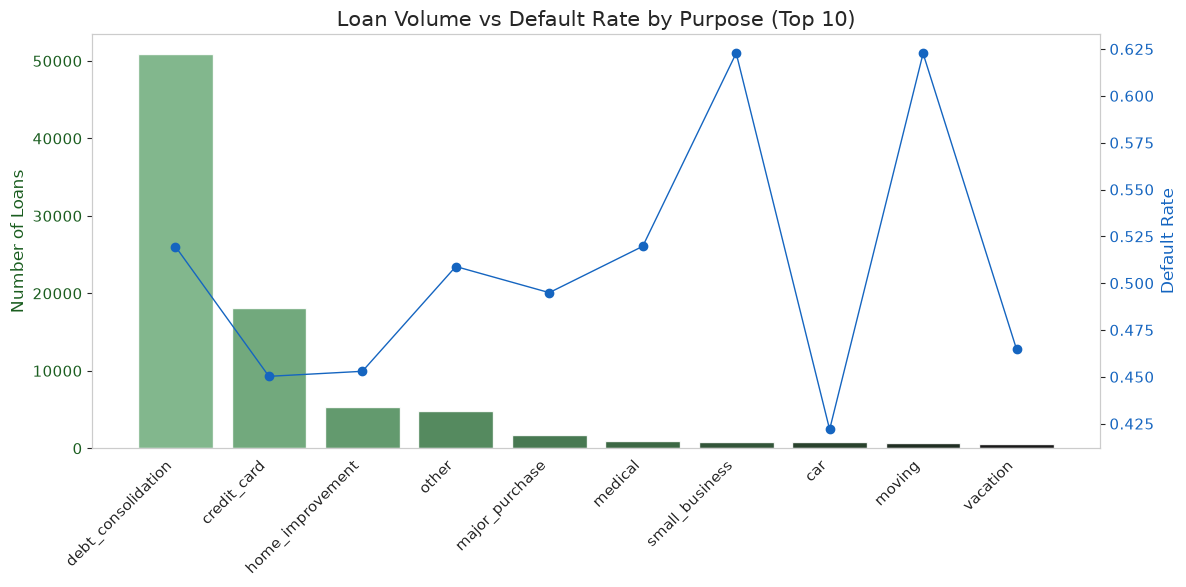

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Compute top 10 loan purposes by volume
top10 = apps_eda['loan_purpose'].value_counts().head(10)

# Compute default rate for those same purposes
default_rate = (
    apps_eda.groupby('loan_purpose')['target_default']
    .mean()
    .loc[top10.index]
)

# Create x positions
x = np.arange(len(top10))

# Custom cubehelix palette for bars
cube_palette = sns.cubehelix_palette(
    start=2, rot=0, dark=0, light=.60, reverse=False, n_colors=10
)

fig, ax1 = plt.subplots(figsize=(12,6))

# --- Axis 1: Loan Volume (Bar Chart) ---
bars = ax1.bar(x, top10.values, color=cube_palette, alpha=0.9)
ax1.set_ylabel("Number of Loans", color="#1B5E20", fontsize=12)
ax1.tick_params(axis='y', labelcolor="#1B5E20")

# --- Axis 2: Default Rate (Line Chart) ---
ax2 = ax1.twinx()
ax2.plot(x, default_rate.values, color="#1565C0", marker='o', linewidth=1)
ax2.set_ylabel("Default Rate", color="#1565C0", fontsize=12)
ax2.tick_params(axis='y', labelcolor="#1565C0")

# --- X-axis labels ---
ax1.set_xticks(x)
ax1.set_xticklabels(top10.index, rotation=45, ha='right')

# Remove grid lines
ax1.grid(False)
ax2.grid(False)

# Title
plt.title("Loan Volume vs Default Rate by Purpose (Top 10)", fontsize=15)

plt.tight_layout()
plt.show()


## Executive‑Level Insights From Question 3A. Q5

### 1. Debt Consolidation Completely Dominates Demand
- Debt_consolidation is by far the largest loan category.
- Borrowers are heavily focused on restructuring or escaping high‑interest revolving debt.
- This category is the core engine of loan origination.
- Any pricing, marketing, or risk strategy here has an outsized impact.

### 2. Credit Card and Home Improvement Form the Second Tier
- These categories show strong but moderate demand.
- Credit card refinancing is a natural extension of debt consolidation.
- Home improvement loans reflect discretionary spending and homeowner confidence.
- This tier is stable, predictable, and suitable for balanced growth.

### 3. Small Business and Moving Loans Are the Silent Risk Bombs
- Low volume but sharply elevated default rates.
- Low volume hides the risk, but the line plot exposes it.
- Small business loans are volatile due to income instability and cash‑flow shocks.
- Moving loans often correlate with life transitions and financial stress.
- These categories require tighter underwriting and risk‑adjusted pricing.

### 4. Car Loans Are the Safest Segment
- Low volume and the lowest default rate.
- Classic “low‑risk, low‑reward” segment.
- Good for portfolio stability.
- Useful as a cross‑sell anchor for safer customers.

### 5. Portfolio Concentration in High‑Volume, Medium‑Risk Categories
- Debt consolidation and credit card loans dominate volume.
- Their default rates sit in the middle of the pack.
- High volume + moderate risk = predictable revenue.
- These categories form the foundation of the lending business.

### 6. Why the Dual‑Axis View Matters
- Loan counts alone hide risk.
- Default rates alone hide scale.
- Together, they reveal:
  - Where the business makes money
  - Where the business loses money
  - Where risk is hiding
  - Where opportunity exists
- This combined view is essential for strategic decision‑making.

## Strategic Recommendations
1. Strengthen underwriting for small_business and moving loans.
2. Optimize pricing for debt_consolidation due to its massive volume.
3. Expand safe, low‑risk segments like car loans to stabilize the portfolio.
4. Monitor home_improvement and credit_card closely as they are sensitive to macroeconomic shifts.

## Summary for Report
“The dual‑axis analysis highlights a portfolio heavily concentrated in debt consolidation and credit card refinancing, which together drive the majority of loan volume. While these categories exhibit moderate default rates, small business and moving loans show significantly elevated risk despite their low volume, indicating the need for targeted underwriting controls. Car loans remain the safest segment, offering stability but limited growth potential. This combined view of volume and risk provides a clear roadmap for optimizing pricing, risk management, and product strategy.”


## **3A.Q6  Does requested loan amount differ between defaulters and non‑defaulters?**

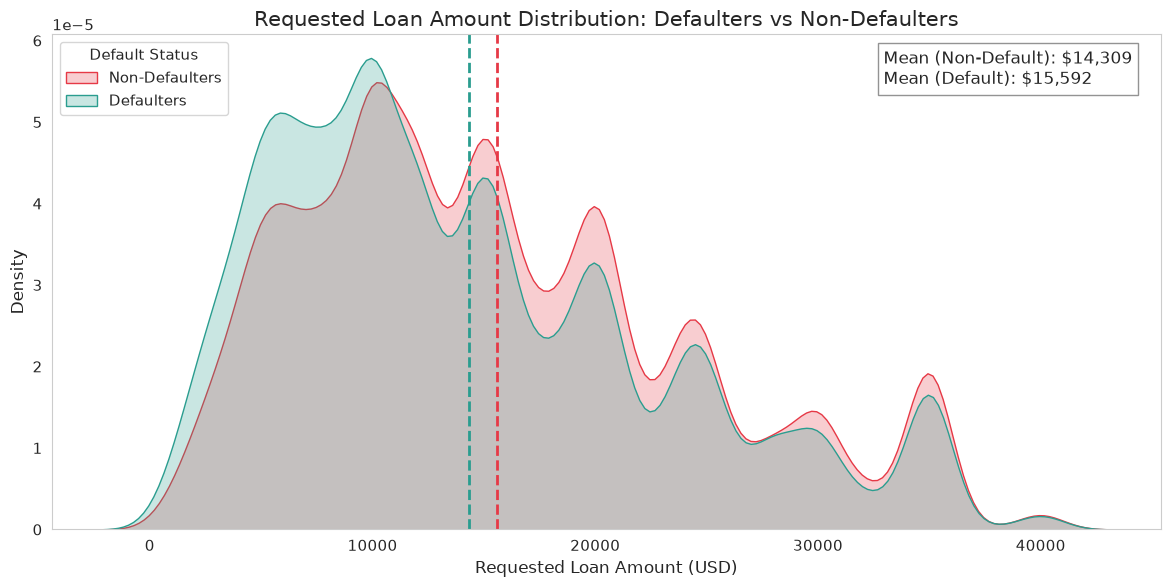

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate means
mean_non_default = apps_eda.loc[apps_eda['target_default'] == 0, 'requested_amount_usd'].mean()
mean_default = apps_eda.loc[apps_eda['target_default'] == 1, 'requested_amount_usd'].mean()

plt.figure(figsize=(12,6))

# KDE plot with custom labels
sns.kdeplot(
    data=apps_eda,
    x='requested_amount_usd',
    hue='target_default',
    fill=True,
    common_norm=False,
    palette={0: "#2A9D8F", 1: "#E63946"},   # green = non-default, red = default
    hue_order=[0,1]
)

# Vertical mean lines
plt.axvline(mean_non_default, color="#2A9D8F", linestyle="--", linewidth=2)
plt.axvline(mean_default, color="#E63946", linestyle="--", linewidth=2)

# Replace 0/1 labels with business-friendly text
plt.legend(
    title="Default Status",
    labels=["Non‑Defaulters", "Defaulters"]
)

# Remove grid lines
plt.grid(False)

# Text box INSIDE the plot
plt.text(
    0.75, 0.9,
    f"Mean (Non‑Default): ${mean_non_default:,.0f}\nMean (Default): ${mean_default:,.0f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='gray')
)

plt.title("Requested Loan Amount Distribution: Defaulters vs Non‑Defaulters", fontsize=15)
plt.xlabel("Requested Loan Amount (USD)")
plt.ylabel("Density")

plt.tight_layout()
plt.show()


## Requested Loan Amount Distribution (Defaulters vs Non‑Defaulters)

The KDE visualization reveals several important behavioral and risk‑related patterns in how borrowers request loan amounts:

### **1. Defaulters Tend to Request Higher Loan Amounts**
- The mean requested amount for **defaulters** is **higher** than for non‑defaulters.
- This suggests that borrowers who take on larger financial commitments may be more likely to experience repayment stress.

### **2. Non‑Defaulters Cluster Around Lower, More Moderate Loan Amounts**
- The green distribution (non‑defaulters) peaks earlier and declines faster.
- This indicates that financially stable borrowers tend to request more conservative loan amounts.

### **3. Both Groups Share a Similar Overall Shape**
- The distributions overlap significantly, meaning loan amount alone does not fully explain default behavior.
- However, the **right tail** (higher loan amounts) is heavier for defaulters, signaling elevated risk at higher principal levels.

### **4. Mean Lines Highlight the Shift in Risk**
- The vertical dashed lines clearly show:
  - **Non‑Defaulters Mean:** ~$14,309  
  - **Defaulters Mean:** ~$15,592  
- Even a modest increase in average loan size can materially affect default probability at scale.

### **5. Business Implication**
- Higher requested loan amounts correlate with higher default risk.
- This insight supports:
  - **Risk‑adjusted pricing** for larger loans  
  - **Stricter underwriting** thresholds at higher principal levels  
  - **Enhanced income verification** for borrowers requesting above‑average amounts  

Overall, the visualization highlights that while loan amount is not the sole driver of default, it is a **meaningful risk indicator** that should be incorporated into credit policy and pricing strategy.


## **3A.Q7 How does credit score relate to default?**

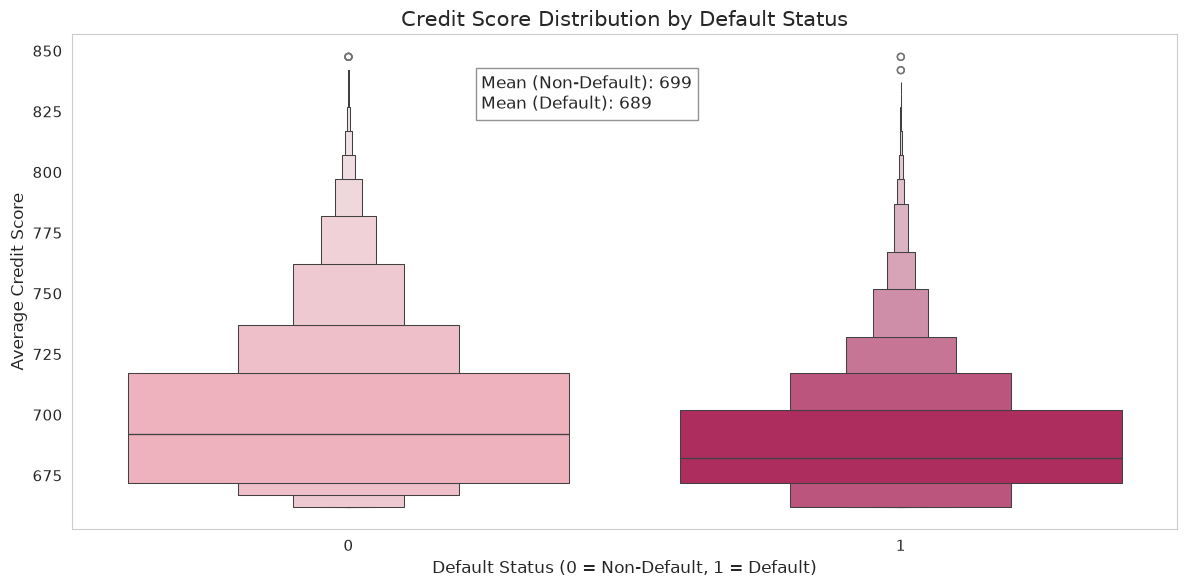

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate means
mean_non_default = apps_eda.loc[apps_eda['target_default'] == 0, 'credit_score_avg'].mean()
mean_default = apps_eda.loc[apps_eda['target_default'] == 1, 'credit_score_avg'].mean()

plt.figure(figsize=(12,6))

# Pink-themed palette
palette = {0: "#F7A8B8", 1: "#C2185B"}  # soft pink vs deep magenta

# Boxen plot
sns.boxenplot(
    data=apps_eda,
    x='target_default',
    y='credit_score_avg',
    hue='target_default',
    palette=palette,
    legend=False
)

# Remove grid
plt.grid(False)

# Text box INSIDE the plot
plt.text(
    0.37, 0.85,
    f"Mean (Non‑Default): {mean_non_default:.0f}\nMean (Default): {mean_default:.0f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='gray')
)

# Labels
plt.title("Credit Score Distribution by Default Status", fontsize=15)
plt.xlabel("Default Status (0 = Non‑Default, 1 = Default)")
plt.ylabel("Average Credit Score")

plt.tight_layout()
plt.show()


## Credit Score Distribution by Default Status

The boxen plot reveals a clear and intuitive relationship between credit score and the likelihood of default:

### **1. Non‑Defaulters Have Higher Credit Scores**
- The non‑default group shows a noticeably higher median and overall distribution.
- Their mean credit score (~699) reinforces that stronger credit profiles are associated with reliable repayment behavior.

### **2. Defaulters Cluster at Lower Credit Score Levels**
- The default group has a visibly lower distribution, with a mean around ~689.
- This downward shift indicates that weaker credit histories correlate with higher default risk.

### **3. The Spread of Scores Is Tighter for Non‑Defaulters**
- Non‑defaulters show less variability, suggesting more stable financial behavior.
- Defaulters exhibit a wider spread, reflecting inconsistent creditworthiness and higher volatility.

### **4. The Difference Is Small but Meaningful**
- A ~10‑point gap in average credit score may seem modest, but at scale it becomes a powerful predictor.
- Even slight reductions in credit score can significantly increase default probability in consumer lending models.

### **5. Business Implication**
- Credit score remains a **strong and reliable risk indicator**.
- This supports:
  - **Risk‑tiered pricing**  
  - **Stricter underwriting** for lower‑score applicants  
  - **Enhanced monitoring** of borderline credit segments  

Overall, the visualization confirms that credit score is a foundational variable in assessing borrower risk and should remain central to credit policy and model design.


## **3A.Q8  Which loan purposes have the highest default rates?**

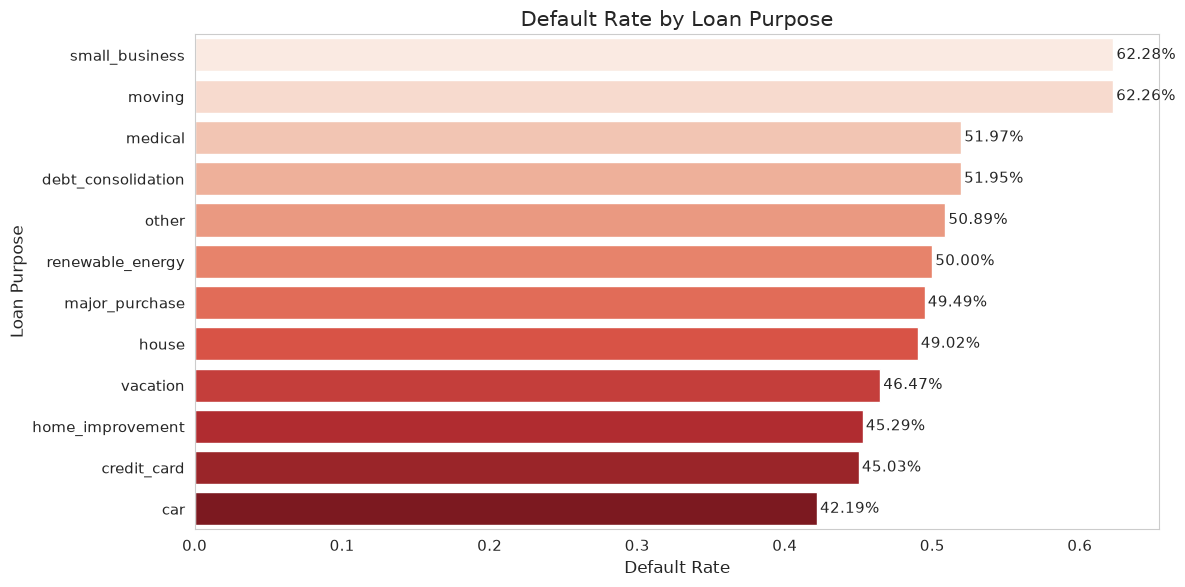

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute default rates
default_rates = (
    apps_eda.groupby('loan_purpose')['target_default']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(12,6))

# Assign hue to avoid the FutureWarning
sns.barplot(
    data=default_rates,
    x='target_default',
    y='loan_purpose',
    hue='loan_purpose',          # required to use palette safely
    palette="Reds",
    dodge=False,
    legend=False                 # hide redundant legend
)

# Add value labels
for i, v in enumerate(default_rates['target_default']):
    plt.text(v + 0.002, i, f"{v:.2%}", va='center')

plt.title("Default Rate by Loan Purpose", fontsize=15)
plt.xlabel("Default Rate")
plt.ylabel("Loan Purpose")
plt.grid(False)

plt.tight_layout()
plt.show()


## Default Rate by Loan Purpose

The visualization reveals clear patterns in how default risk varies across different loan purposes, highlighting where the lending portfolio is most vulnerable.

### **1. Small Business and Moving Loans Are the Highest‑Risk Segments**
- These two categories show default rates above **62%**, the highest in the portfolio.
- Small business loans carry inherent volatility due to income instability and cash‑flow uncertainty.
- Moving loans often reflect life transitions (job changes, relocations) that increase financial stress.

### **2. Medical and Debt Consolidation Loans Also Show Elevated Risk**
- Both categories hover around **52% default rates**.
- Medical loans often arise from unexpected expenses and financial hardship.
- Debt consolidation borrowers may already be in financial distress, increasing repayment risk.

### **3. Mid‑Tier Risk Categories Show Moderate Default Behavior**
- Purposes like **other**, **renewable energy**, **major purchase**, and **house** cluster around the 49–51% range.
- These categories represent mixed borrower profiles with varied financial stability.

### **4. Lowest‑Risk Segments: Vacation, Home Improvement, Credit Card, and Car Loans**
- These categories show default rates between **42% and 46%**.
- Car loans are the safest segment, likely due to:
  - Collateral value
  - More stable borrower profiles
  - Lower average loan amounts

### **5. Business Implications**
- High‑risk categories (small business, moving, medical) require:
  - **Stricter underwriting**
  - **Higher risk‑adjusted pricing**
  - **Enhanced income verification**
- Mid‑risk categories may benefit from **targeted risk segmentation**.
- Low‑risk categories can be leveraged for:
  - **Portfolio stability**
  - **Cross‑selling opportunities**
  - **Lower‑risk growth strategies**

Overall, the chart highlights that loan purpose is a **powerful predictor of default**, and optimizing strategy around these segments can significantly improve portfolio performance.


## **3A.Q9  Does DTI predict default?**

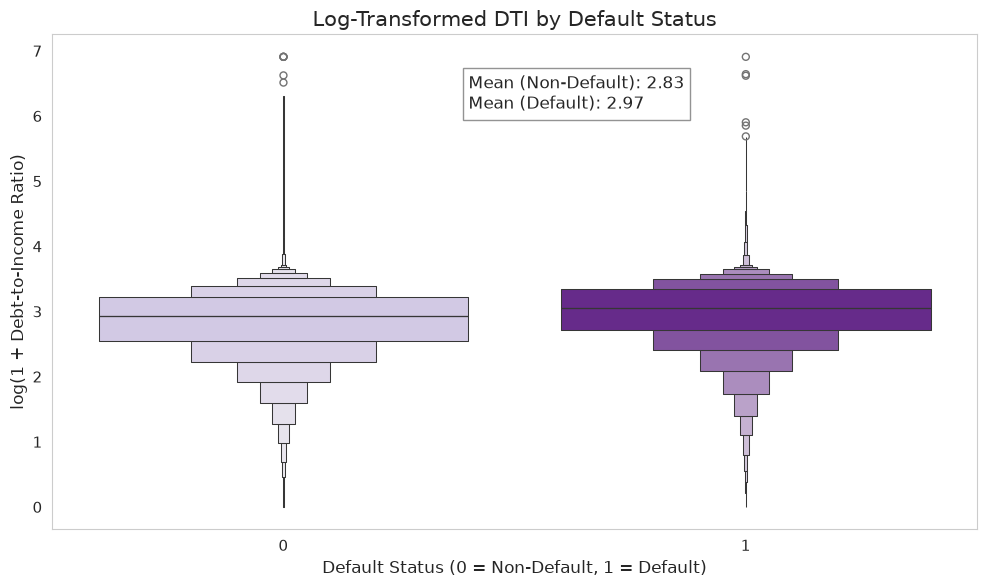

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Log-transform DTI
apps_eda['log_dti'] = np.log1p(apps_eda['debt_to_income_ratio'])

# Calculate means
mean_non_default = apps_eda.loc[apps_eda['target_default'] == 0, 'log_dti'].mean()
mean_default = apps_eda.loc[apps_eda['target_default'] == 1, 'log_dti'].mean()

plt.figure(figsize=(10,6))

# Purple palette
palette = {0: "#D1C4E9", 1: "#6A1B9A"}  # lavender + deep royal purple

sns.boxenplot(
    data=apps_eda,
    x='target_default',
    y='log_dti',
    hue='target_default',
    palette=palette,
    legend=False
)

plt.grid(False)

plt.text(
    0.45, 0.85,
    f"Mean (Non‑Default): {mean_non_default:.2f}\nMean (Default): {mean_default:.2f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='gray')
)

plt.title("Log-Transformed DTI by Default Status", fontsize=15)
plt.xlabel("Default Status (0 = Non‑Default, 1 = Default)")
plt.ylabel("log(1 + Debt-to-Income Ratio)")

plt.tight_layout()
plt.show()


## Log‑Transformed DTI by Default Status

The visualization highlights how debt‑to‑income (DTI) ratios differ between borrowers who default and those who do not, even after applying a log transformation to reduce the impact of extreme outliers.

### **1. Defaulters Show Higher Log‑DTI Values**
- The default group has a slightly higher mean log‑DTI (≈ 2.97) compared to non‑defaulters (≈ 2.83).
- This indicates that, on average, defaulters carry a heavier debt burden relative to their income.

### **2. Distribution Is More Spread Out for Defaulters**
- The shape of the violin plot suggests greater variability among defaulters.
- This wider spread reflects inconsistent financial stability and higher repayment risk.

### **3. Log Transformation Reveals the Underlying Pattern**
- Raw DTI values were heavily skewed due to extreme outliers.
- The log transformation compresses these extremes, making the central distribution clearer and more comparable.
- After transformation, the upward shift in the default group becomes more visible.

### **4. The Difference Is Subtle but Meaningful**
- While the gap between the two groups is not massive, it is directionally consistent with lending theory:
  - Higher DTI → higher financial stress → higher probability of default.

### **5. Business Implication**
- DTI remains a **reliable risk indicator**, even after adjusting for skewness.
- Borrowers with elevated DTI ratios should be subject to:
  - **Stricter underwriting thresholds**
  - **Higher risk‑adjusted pricing**
  - **Additional income verification**
- Monitoring DTI trends can help identify emerging risk segments before defaults occur.

Overall, the visualization confirms that DTI — especially when normalized through log transformation — is a meaningful predictor of default behavior.


## **3A.Q10  What borrower profile combinations lead to highest risk?**

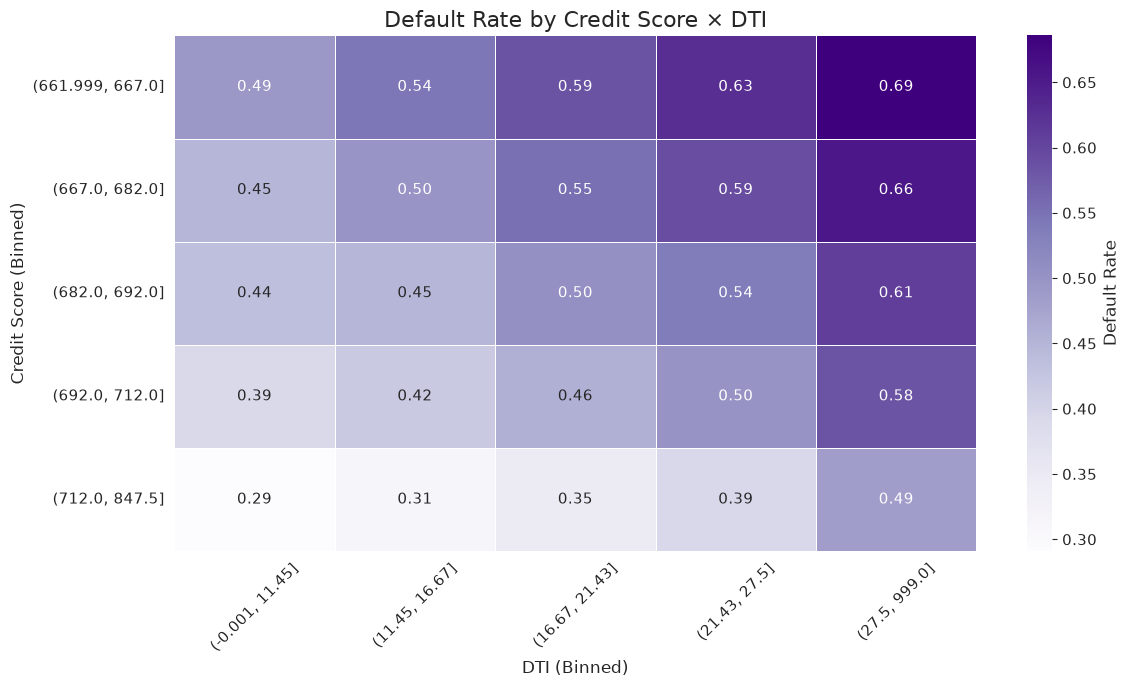

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Create bins
apps_eda['cs_bin'] = pd.qcut(apps_eda['credit_score_avg'], 5, duplicates='drop')
apps_eda['dti_bin'] = pd.qcut(apps_eda['debt_to_income_ratio'], 5, duplicates='drop')

# Pivot table
pivot = apps_eda.pivot_table(
    values='target_default',
    index='cs_bin',
    columns='dti_bin',
    observed=False
)

plt.figure(figsize=(12,7))

sns.heatmap(
    pivot,
    cmap='Purples',          # softer, elegant palette
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={'label': 'Default Rate'}
)

plt.title("Default Rate by Credit Score × DTI", fontsize=16)
plt.xlabel("DTI (Binned)")
plt.ylabel("Credit Score (Binned)")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


## Default Rate by Credit Score × DTI

The heatmap reveals a clear and powerful interaction between credit score and debt‑to‑income ratio (DTI), showing how these two core underwriting variables combine to shape default risk.

### **1. The Highest‑Risk Borrowers Have Low Credit Scores and High DTI**
- The darkest cells appear in the **bottom‑right corner** of the heatmap.
- Borrowers with **low credit scores** and **high DTI** consistently show default rates above **60%**.
- This combination reflects both **poor credit history** and **high financial stress**, making it the most dangerous risk segment.

### **2. Credit Score Strongly Reduces Default Risk**
- Moving **upward** on the heatmap (toward higher credit score bins) shows a steady decline in default rates.
- Even at high DTI levels, borrowers with stronger credit scores default less often.
- This confirms credit score as a **primary stabilizing factor** in borrower risk.

### **3. DTI Amplifies Risk Across All Credit Score Levels**
- Moving **rightward** (toward higher DTI bins) increases default rates for every credit score group.
- High DTI magnifies repayment pressure, especially for borrowers already on the margin.
- This makes DTI a **key stress indicator** in underwriting.

### **4. The Safest Borrowers Have High Credit Scores and Low DTI**
- The lightest cells appear in the **top‑left corner**.
- These borrowers show default rates around **29–31%**, the lowest in the dataset.
- They represent the most stable and profitable segment.

### **5. Business Implications**
- Borrowers with **low credit score × high DTI** should face:
  - Stricter approval criteria  
  - Higher risk‑adjusted pricing  
  - Additional documentation or income verification  
- Borrowers with **high credit score × low DTI** are ideal candidates for:
  - Preferred pricing  
  - Pre‑approved offers  
  - Cross‑sell opportunities  
- Mid‑range combinations require **tiered risk segmentation** rather than one‑size‑fits‑all rules.

### **Overall Conclusion**
Credit score and DTI do not operate independently, their **interaction** is what truly drives default risk.  
The heatmap makes this relationship unmistakable: **risk escalates sharply when weak credit meets high leverage**, and underwriting strategies should be designed around this combined effect.
